Run PC algorithm to learn DAG

In [9]:
from pgmpy.utils import get_example_model

# Load the built-in E. coli Bayesian network
ecoli_model = get_example_model("ecoli70")

# Generate the same type of dataset used in the docs
ecoli_df = ecoli_model.simulate(1000)

#print(ecoli_df.shape)
ecoli_df.head()

,b1191,cspG,eutG,fixC,cspA,yecO,yedE,sucA,cchB,yceP,...,dnaK,folK,ycgX,lacZ,nuoM,dnaG,b1583,mopB,yaeM,ftsJ
0,0.800884,3.164703,1.951446,-0.983005,-0.726081,2.878474,-2.873014,-0.924031,0.767609,2.464185,...,-0.517856,1.389313,2.171087,3.679700,-0.951662,1.874087,1.796326,-0.319226,4.001796,0.257661
1,2.261069,1.424744,-0.033783,2.915992,-0.886760,1.699597,-1.367776,-0.494618,2.575325,-1.352666,...,1.496319,2.298111,1.321480,1.818120,-0.783593,1.225574,-1.193708,-0.183405,3.413478,0.534687
2,1.477346,3.264896,2.051044,1.290235,1.918183,2.819689,-1.138884,-1.939136,1.684272,1.395341,...,-0.896886,0.321208,-0.906081,1.934928,-0.873901,-0.202020,1.444963,-1.191875,6.296325,-0.771058
3,1.152651,1.775705,1.127235,-0.237578,-1.268806,2.031840,-0.733375,0.335504,1.841574,1.423858,...,1.633844,1.436673,1.888969,0.735653,-2.465393,1.346957,1.993865,0.818131,3.011250,2.372887
4,0.083157,1.999220,-0.551076,-0.050953,-1.156394,1.631823,-1.003649,-0.477735,2.067998,-0.678234,...,0.529560,-0.659179,-0.654718,5.149081,0.790160,-0.604430,1.707161,-0.849686,3.673793,-0.467185


Learn structure with PC

In [14]:
from pgmpy.utils import get_example_model

# Load the true ecoli70 network
true_model = get_example_model("ecoli70")

# Generate synthetic dataset
ecoli_df = true_model.simulate(1000)
print("Loaded model with", len(true_model.nodes()), "nodes")


Loaded model with 46 nodes


In [3]:
from pgmpy.estimators import PC

pc = PC(ecoli_df)

learned_dag = pc.estimate(
    ci_test="pearsonr",
    return_type="dag",
    variant="stable",
    significance_level=0.05
)

print("Learned edges:", len(learned_dag.edges()))

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'b1191': 'N', 'cspG': 'N', 'eutG': 'N', 'fixC': 'N', 'cspA': 'N', 'yecO': 'N', 'yedE': 'N', 'sucA': 'N', 'cchB': 'N', 'yceP': 'N', 'ygbD': 'N', 'yjbO': 'N', 'yfiA': 'N', 'lpdA': 'N', 'pspB': 'N', 'atpG': 'N', 'dnaJ': 'N', 'flgD': 'N', 'gltA': 'N', 'sucD': 'N', 'tnaA': 'N', 'ygcE': 'N', 'yhdM': 'N', 'ibpB': 'N', 'yfaD': 'N', 'hupB': 'N', 'pspA': 'N', 'asnA': 'N', 'atpD': 'N', 'nmpC': 'N', 'icdA': 'N', 'lacA': 'N', 'yheI': 'N', 'aceB': 'N', 'lacY': 'N', 'b1963': 'N', 'dnaK': 'N', 'folK': 'N', 'ycgX': 'N', 'lacZ': 'N', 'nuoM': 'N', 'dnaG': 'N', 'b1583': 'N', 'mopB': 'N', 'yaeM': 'N', 'ftsJ': 'N'}
Working for n conditional variables: 5: 100%|██████████| 5/5 [00:23<00:00,  4.65s/it]


Learned edges: 52


Compare true vs learned edges

In [4]:
# True edges from the model
true_edges = set(true_model.edges())

# Learned edges
learned_edges = set(learned_dag.edges())

# Metrics
true_positives = len(true_edges & learned_edges)
false_positives = len(learned_edges - true_edges)
false_negatives = len(true_edges - learned_edges)

precision = true_positives / (true_positives + false_positives + 1e-9)
recall = true_positives / (true_positives + false_negatives + 1e-9)

print(f"True edges: {len(true_edges)}")
print(f"Learned edges: {len(learned_edges)}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")

True edges: 70
Learned edges: 52
Precision: 0.442
Recall: 0.329


In [5]:
print("\n Missed true edges:")
for e in list(true_edges - learned_edges)[:10]:
    print(e)

print("\n Extra edges (false positives):")
for e in list(learned_edges - true_edges)[:10]:
    print(e)


 Missed true edges:
('fixC', 'ycgX')
('ygcE', 'atpD')
('yedE', 'yheI')
('yceP', 'ibpB')
('lacZ', 'b1583')
('yheI', 'dnaG')
('asnA', 'lacZ')
('cspG', 'lacY')
('asnA', 'lacY')
('lacZ', 'mopB')

 Extra edges (false positives):
('atpD', 'b1963')
('b1963', 'folK')
('atpG', 'sucD')
('atpG', 'eutG')
('pspA', 'yedE')
('flgD', 'sucA')
('icdA', 'ygcE')
('ygbD', 'tnaA')
('dnaK', 'yheI')
('ftsJ', 'atpD')


In [6]:
import networkx as nx

# Convert true model
G_true = nx.DiGraph()
G_true.add_nodes_from(true_model.nodes())
G_true.add_edges_from(true_model.edges())

# Convert learned DAG
G_learned = nx.DiGraph()
G_learned.add_nodes_from(learned_dag.nodes())
G_learned.add_edges_from(learned_dag.edges())

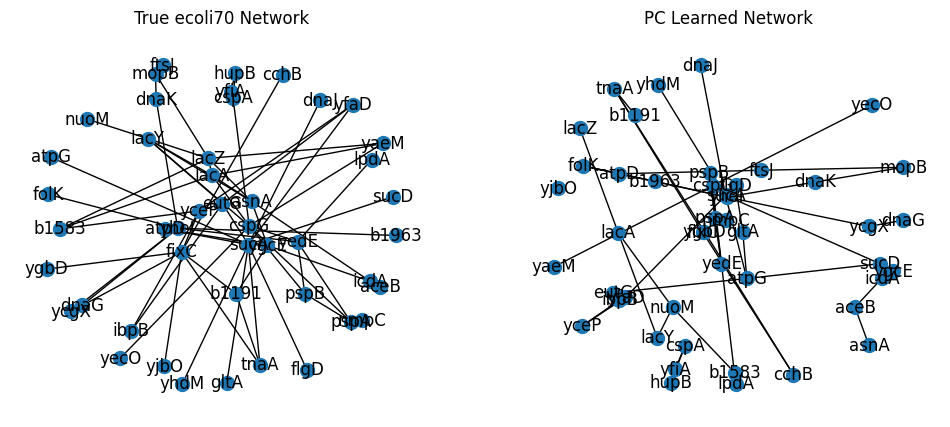

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# True graph
plt.subplot(1, 2, 1)
pos = nx.spring_layout(G_true, seed=42)
nx.draw(G_true, pos, node_size=100, with_labels=True, arrows=False)
plt.title("True ecoli70 Network")

# Learned graph
plt.subplot(1, 2, 2)
pos2 = nx.spring_layout(G_learned, seed=42)
nx.draw(G_learned, pos2, node_size=100, with_labels=True, arrows=False)
plt.title("PC Learned Network")

plt.show()